# Análise Preditiva de Contratos Públicos de Recife

Este notebook implementa modelos de Machine Learning para:
- Predição de valores contratuais
- Classificação automática de tipos de contratos
- Detecção de anomalias

## Pré-requisitos

Execute os notebooks anteriores (`pe_recife.ipynb` e `pe_recife_intermedium.ipynb`) para gerar os datasets necessários.

## 1. Configuração Inicial e Importação de Bibliotecas

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
from collections import Counter
import re
import unicodedata

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de Regressão
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Modelos de Classificação
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Detecção de Anomalias
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor

# Métricas
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support
)

# Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Configurações do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Suprimir avisos
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
np.random.seed(42)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

In [3]:
# Carregar dados
data_path = '../../../data/pe/recife/dados_abertos_contratos.csv'
df = pd.read_csv(data_path, sep=';', encoding='utf-8', low_memory=False)

# Preparação básica
df['datainiciovigencia'] = pd.to_datetime(df['datainiciovigencia'], format='%Y/%m/%d %H:%M:%S.%f', errors='coerce')
df['datafimvigencia'] = pd.to_datetime(df['datafimvigencia'], format='%Y/%m/%d %H:%M:%S.%f', errors='coerce')
df['valorcontrato1'] = pd.to_numeric(df['valorcontrato1'], errors='coerce')
df['valorcontrato2'] = pd.to_numeric(df['valorcontrato2'], errors='coerce')

# Criar features derivadas
df['ano_inicio'] = df['datainiciovigencia'].dt.year
df['mes_inicio'] = df['datainiciovigencia'].dt.month
df['duracao_dias'] = (df['datafimvigencia'] - df['datainiciovigencia']).dt.days
df['tipo_contratado'] = df.apply(
    lambda x: 'PJ' if pd.notna(x['cnpjcontratado']) else ('PF' if pd.notna(x['cpfcontratado']) else 'Desconhecido'),
    axis=1
)
df['fornecedor_local'] = df['estadoendcontratado'].apply(
    lambda x: 1 if x == 'PE' else 0 if pd.notna(x) else np.nan
)

print(f"Dataset carregado: {len(df):,} contratos")
print(f"Período: {df['anocontrato'].min()} a {df['anocontrato'].max()}")
print(f"\nPrimeiras features criadas:")
print(f"  - ano_inicio, mes_inicio")
print(f"  - duracao_dias")
print(f"  - tipo_contratado")
print(f"  - fornecedor_local")

Dataset carregado: 8,202 contratos
Período: 2004.0 a 2026.0

Primeiras features criadas:
  - ano_inicio, mes_inicio
  - duracao_dias
  - tipo_contratado
  - fornecedor_local


## 3. Feature Engineering Avançado

### 3.1 Processamento de Texto (TF-IDF)

In [4]:
# Função para limpar texto
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('ASCII')
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Limpar objetos contratuais
df['objeto_limpo'] = df['objetocontrato'].apply(clean_text)

# Stopwords customizadas
stopwords_pt = [
    'a', 'o', 'e', 'de', 'da', 'do', 'em', 'para', 'com', 'por', 'na', 'no',
    'ao', 'aos', 'das', 'dos', 'um', 'uma', 'os', 'as', 'que', 'se', 'ou',
    'anexo', 'edital', 'termo', 'referencia', 'lote', 'item'
]

print("Processamento de texto concluído!")
print(f"Total de contratos com objeto: {df['objeto_limpo'].str.len().gt(0).sum():,}")

Processamento de texto concluído!
Total de contratos com objeto: 8,199


### 3.2 Categorização de Contratos

In [5]:
# Definir categorias
categories = {
    'Infraestrutura e Obras': ['obra', 'construcao', 'reforma', 'recuperacao', 'pavimentacao'],
    'Serviços de TI': ['software', 'sistema', 'informatica', 'tecnologia', 'dados'],
    'Saúde': ['saude', 'hospital', 'medico', 'enfermagem', 'ambulancia'],
    'Educação': ['educacao', 'escola', 'ensino', 'professor', 'aluno'],
    'Limpeza e Manutenção': ['limpeza', 'manutencao', 'conservacao', 'jardinagem'],
    'Segurança': ['seguranca', 'vigilancia', 'monitoramento', 'alarme'],
    'Transporte e Veículos': ['transporte', 'veiculo', 'onibus', 'caminhao', 'frota'],
    'Locação de Imóveis': ['locacao imovel', 'aluguel', 'locacao nao residencial'],
    'Alimentação': ['alimentacao', 'merenda', 'refeicao', 'refeitorio'],
    'Consultoria e Assessoria': ['consultoria', 'assessoria', 'apoio tecnico', 'capacitacao']
}

def categorize_contract(text):
    text = str(text).lower()
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in text:
                return category
    return 'Outros'

df['categoria'] = df['objeto_limpo'].apply(categorize_contract)

print("Categorização concluída!")
print(f"\nDistribuição de categorias:")
print(df['categoria'].value_counts())

Categorização concluída!

Distribuição de categorias:
categoria
Outros                      3595
Infraestrutura e Obras      1213
Serviços de TI               759
Transporte e Veículos        759
Limpeza e Manutenção         728
Educação                     449
Saúde                        428
Consultoria e Assessoria     145
Segurança                     81
Alimentação                   34
Locação de Imóveis            11
Name: count, dtype: int64


### 3.3 Features Agregadas

In [6]:
# Features baseadas em histórico do fornecedor
supplier_stats = df.groupby('razaonomecontratado').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['mean', 'median', 'sum', 'std'],
    'orgaocontratante': lambda x: x.nunique()
})
supplier_stats.columns = ['_'.join(col).strip() for col in supplier_stats.columns.values]
supplier_stats.columns = [
    'fornecedor_num_contratos', 'fornecedor_valor_medio', 'fornecedor_valor_mediano',
    'fornecedor_valor_total', 'fornecedor_valor_std', 'fornecedor_num_orgaos'
]
supplier_stats = supplier_stats.reset_index()

# Features baseadas em histórico do órgão
agency_stats = df.groupby('orgaocontratante').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['mean', 'median', 'sum'],
    'razaonomecontratado': lambda x: x.nunique()
})
agency_stats.columns = ['_'.join(col).strip() for col in agency_stats.columns.values]
agency_stats.columns = [
    'orgao_num_contratos', 'orgao_valor_medio', 'orgao_valor_mediano',
    'orgao_valor_total', 'orgao_num_fornecedores'
]
agency_stats = agency_stats.reset_index()

# Merge com dataset principal
df = df.merge(supplier_stats, on='razaonomecontratado', how='left')
df = df.merge(agency_stats, on='orgaocontratante', how='left')

print("Features agregadas criadas!")
print(f"\nNovas features do fornecedor:")
print(f"  - fornecedor_num_contratos")
print(f"  - fornecedor_valor_medio/mediano/total/std")
print(f"  - fornecedor_num_orgaos")
print(f"\nNovas features do órgão:")
print(f"  - orgao_num_contratos")
print(f"  - orgao_valor_medio/mediano/total")
print(f"  - orgao_num_fornecedores")

Features agregadas criadas!

Novas features do fornecedor:
  - fornecedor_num_contratos
  - fornecedor_valor_medio/mediano/total/std
  - fornecedor_num_orgaos

Novas features do órgão:
  - orgao_num_contratos
  - orgao_valor_medio/mediano/total
  - orgao_num_fornecedores


---

# PARTE 1: PREDIÇÃO DE VALORES CONTRATUAIS

## 4. Preparação dos Dados para Regressão

In [7]:
# Selecionar features para predição de valor
regression_features = [
    'anocontrato', 'mes_inicio', 'duracao_dias',
    'fornecedor_local', 'fornecedor_num_contratos', 'fornecedor_valor_medio',
    'fornecedor_valor_mediano', 'fornecedor_num_orgaos',
    'orgao_num_contratos', 'orgao_valor_medio', 'orgao_valor_mediano',
    'orgao_num_fornecedores', 'origemcontrato', 'categoria', 'tipo_contratado'
]

# Criar dataset para regressão
df_reg = df[regression_features + ['valorcontrato1']].copy()

# Remover valores extremos e nulos
df_reg = df_reg[(df_reg['valorcontrato1'] > 0) & (df_reg['valorcontrato1'] < df_reg['valorcontrato1'].quantile(0.99))]
df_reg = df_reg.dropna(subset=['valorcontrato1'])

# Aplicar log transform no target (valores muito assimétricos)
df_reg['log_valorcontrato1'] = np.log1p(df_reg['valorcontrato1'])

print("Dados preparados para regressão!")
print(f"\nDataset:")
print(f"  - Total de registros: {len(df_reg):,}")
print(f"  - Features: {len(regression_features)}")
print(f"  - Target: log_valorcontrato1")
print(f"\nDistribuição do target (log):")
print(df_reg['log_valorcontrato1'].describe())

Dados preparados para regressão!

Dataset:
  - Total de registros: 3,679
  - Features: 15
  - Target: log_valorcontrato1

Distribuição do target (log):
count   3,679.00
mean       12.16
std         2.06
min         0.00
25%        10.77
50%        12.02
75%        13.51
max        17.42
Name: log_valorcontrato1, dtype: float64


### 4.1 Divisão Train/Test e Encoding

In [8]:
# Separar features e target
X_reg = df_reg[regression_features].copy()
y_reg = df_reg['log_valorcontrato1'].copy()

# Identificar colunas categóricas e numéricas
categorical_features = ['origemcontrato', 'categoria', 'tipo_contratado']
numerical_features = [col for col in regression_features if col not in categorical_features]

# Divisão train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Criar transformadores
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Dados divididos e preparados!")
print(f"\nTrain set: {len(X_train_reg):,} registros")
print(f"Test set: {len(X_test_reg):,} registros")
print(f"\nFeatures numéricas: {len(numerical_features)}")
print(f"Features categóricas: {len(categorical_features)}")

Dados divididos e preparados!

Train set: 2,943 registros
Test set: 736 registros

Features numéricas: 12
Features categóricas: 3


## 5. Treinamento de Modelos de Regressão

### 5.1 Baseline: Regressão Linear

In [9]:
# Criar pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Treinar
print("Treinando Regressão Linear...")
lr_pipeline.fit(X_train_reg, y_train_reg)

# Predições
y_pred_train_lr = lr_pipeline.predict(X_train_reg)
y_pred_test_lr = lr_pipeline.predict(X_test_reg)

# Métricas
print("\nRESULTADOS - REGRESSÃO LINEAR")
print("=" * 80)
print(f"\nTrain Set:")
print(f"  - MAE: {mean_absolute_error(y_train_reg, y_pred_train_lr):.4f}")
print(f"  - RMSE: {np.sqrt(mean_squared_error(y_train_reg, y_pred_train_lr)):.4f}")
print(f"  - R²: {r2_score(y_train_reg, y_pred_train_lr):.4f}")

print(f"\nTest Set:")
print(f"  - MAE: {mean_absolute_error(y_test_reg, y_pred_test_lr):.4f}")
print(f"  - RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_test_lr)):.4f}")
print(f"  - R²: {r2_score(y_test_reg, y_pred_test_lr):.4f}")

# Salvar métricas
results_regression = {
    'Linear Regression': {
        'train_mae': mean_absolute_error(y_train_reg, y_pred_train_lr),
        'train_rmse': np.sqrt(mean_squared_error(y_train_reg, y_pred_train_lr)),
        'train_r2': r2_score(y_train_reg, y_pred_train_lr),
        'test_mae': mean_absolute_error(y_test_reg, y_pred_test_lr),
        'test_rmse': np.sqrt(mean_squared_error(y_test_reg, y_pred_test_lr)),
        'test_r2': r2_score(y_test_reg, y_pred_test_lr)
    }
}

Treinando Regressão Linear...

RESULTADOS - REGRESSÃO LINEAR

Train Set:
  - MAE: 1.2886
  - RMSE: 1.6883
  - R²: 0.3268

Test Set:
  - MAE: 1.3028
  - RMSE: 1.6713
  - R²: 0.3485


### 5.2 Random Forest Regressor

In [10]:
# Criar pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, 
                                        min_samples_split=10, random_state=42, n_jobs=-1))
])

# Treinar
print("Treinando Random Forest...")
rf_pipeline.fit(X_train_reg, y_train_reg)

# Predições
y_pred_train_rf = rf_pipeline.predict(X_train_reg)
y_pred_test_rf = rf_pipeline.predict(X_test_reg)

# Métricas
print("\nRESULTADOS - RANDOM FOREST")
print("=" * 80)
print(f"\nTrain Set:")
print(f"  - MAE: {mean_absolute_error(y_train_reg, y_pred_train_rf):.4f}")
print(f"  - RMSE: {np.sqrt(mean_squared_error(y_train_reg, y_pred_train_rf)):.4f}")
print(f"  - R²: {r2_score(y_train_reg, y_pred_train_rf):.4f}")

print(f"\nTest Set:")
print(f"  - MAE: {mean_absolute_error(y_test_reg, y_pred_test_rf):.4f}")
print(f"  - RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_test_rf)):.4f}")
print(f"  - R²: {r2_score(y_test_reg, y_pred_test_rf):.4f}")

# Salvar métricas
results_regression['Random Forest'] = {
    'train_mae': mean_absolute_error(y_train_reg, y_pred_train_rf),
    'train_rmse': np.sqrt(mean_squared_error(y_train_reg, y_pred_train_rf)),
    'train_r2': r2_score(y_train_reg, y_pred_train_rf),
    'test_mae': mean_absolute_error(y_test_reg, y_pred_test_rf),
    'test_rmse': np.sqrt(mean_squared_error(y_test_reg, y_pred_test_rf)),
    'test_r2': r2_score(y_test_reg, y_pred_test_rf)
}


RESULTADOS - RANDOM FOREST

Train Set:
  - MAE: 0.4671
  - RMSE: 0.7035
  - R²: 0.8831

Test Set:
  - MAE: 0.7244
  - RMSE: 1.0754
  - R²: 0.7302


### 5.3 Gradient Boosting Regressor

In [11]:
# Criar pipeline
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                            learning_rate=0.1, random_state=42))
])

# Treinar
print("Treinando Gradient Boosting...")
gb_pipeline.fit(X_train_reg, y_train_reg)

# Predições
y_pred_train_gb = gb_pipeline.predict(X_train_reg)
y_pred_test_gb = gb_pipeline.predict(X_test_reg)

# Métricas
print("\nRESULTADOS - GRADIENT BOOSTING")
print("=" * 80)
print(f"\nTrain Set:")
print(f"  - MAE: {mean_absolute_error(y_train_reg, y_pred_train_gb):.4f}")
print(f"  - RMSE: {np.sqrt(mean_squared_error(y_train_reg, y_pred_train_gb)):.4f}")
print(f"  - R²: {r2_score(y_train_reg, y_pred_train_gb):.4f}")

print(f"\nTest Set:")
print(f"  - MAE: {mean_absolute_error(y_test_reg, y_pred_test_gb):.4f}")
print(f"  - RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_test_gb)):.4f}")
print(f"  - R²: {r2_score(y_test_reg, y_pred_test_gb):.4f}")

# Salvar métricas
results_regression['Gradient Boosting'] = {
    'train_mae': mean_absolute_error(y_train_reg, y_pred_train_gb),
    'train_rmse': np.sqrt(mean_squared_error(y_train_reg, y_pred_train_gb)),
    'train_r2': r2_score(y_train_reg, y_pred_train_gb),
    'test_mae': mean_absolute_error(y_test_reg, y_pred_test_gb),
    'test_rmse': np.sqrt(mean_squared_error(y_test_reg, y_pred_test_gb)),
    'test_r2': r2_score(y_test_reg, y_pred_test_gb)
}


RESULTADOS - GRADIENT BOOSTING

Train Set:
  - MAE: 0.5346
  - RMSE: 0.7551
  - R²: 0.8653

Test Set:
  - MAE: 0.7329
  - RMSE: 1.0789
  - R²: 0.7285


### 5.4 Comparação de Modelos

In [12]:
# Criar DataFrame com resultados
results_df = pd.DataFrame(results_regression).T

print("COMPARAÇÃO DE MODELOS DE REGRESSÃO")
print("=" * 80)
display(results_df)

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² Score
axes[0, 0].bar(results_df.index, results_df['test_r2'], alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('R² Score no Test Set', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].grid(axis='y', alpha=0.3)

# MAE
axes[0, 1].bar(results_df.index, results_df['test_mae'], alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Mean Absolute Error no Test Set', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(axis='y', alpha=0.3)

# RMSE
axes[1, 0].bar(results_df.index, results_df['test_rmse'], alpha=0.7, color='green', edgecolor='black')
axes[1, 0].set_ylabel('RMSE')
axes[1, 0].set_title('Root Mean Squared Error no Test Set', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(axis='y', alpha=0.3)

# Scatter: Predito vs Real (melhor modelo)
best_model_name = results_df['test_r2'].idxmax()
if best_model_name == 'Random Forest':
    y_pred_best = y_pred_test_rf
elif best_model_name == 'Gradient Boosting':
    y_pred_best = y_pred_test_gb
else:
    y_pred_best = y_pred_test_lr

axes[1, 1].scatter(y_test_reg, y_pred_best, alpha=0.3, s=10)
axes[1, 1].plot([y_test_reg.min(), y_test_reg.max()], 
                [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('Valor Real (log)')
axes[1, 1].set_ylabel('Valor Predito (log)')
axes[1, 1].set_title(f'Predito vs Real - {best_model_name}', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMelhor modelo: {best_model_name} (R² = {results_df.loc[best_model_name, 'test_r2']:.4f})")


Melhor modelo: Random Forest (R² = 0.7302)


### 5.5 Importância das Features (Random Forest)

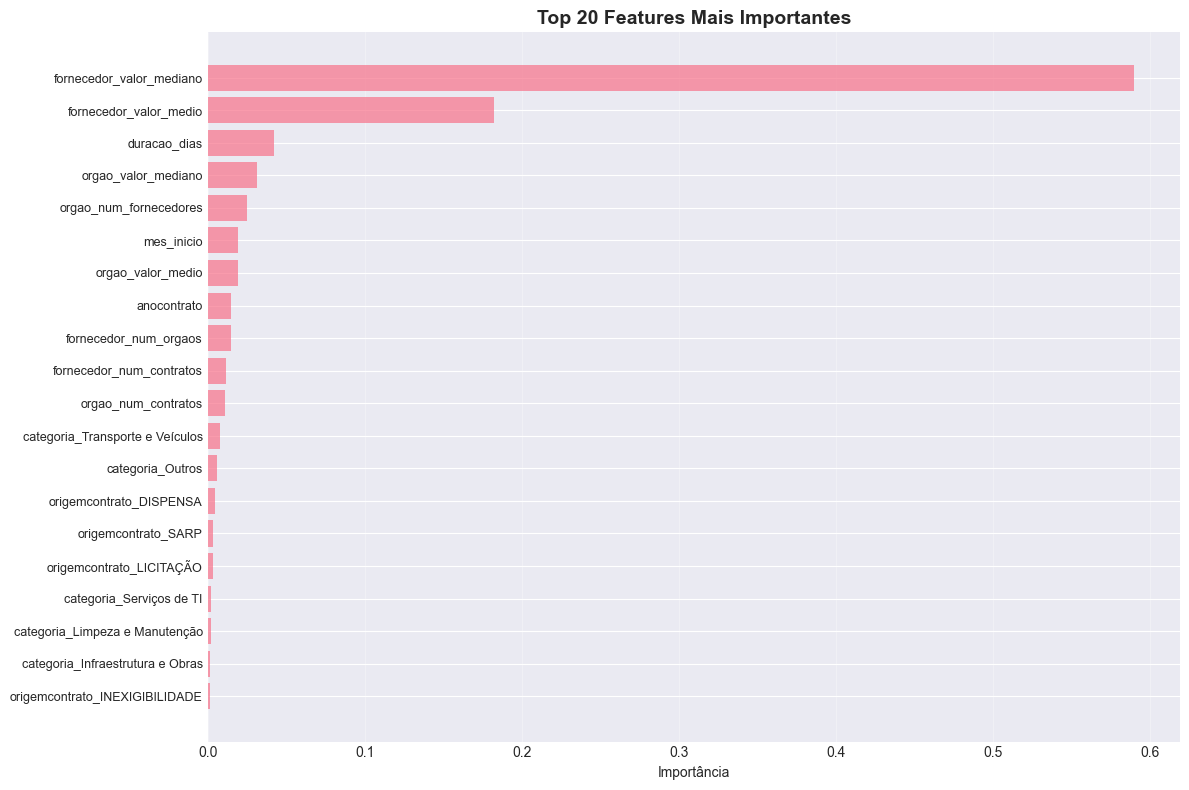

In [13]:
# Obter feature importances do Random Forest
rf_model = rf_pipeline.named_steps['regressor']
feature_names = (numerical_features + 
                list(rf_pipeline.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_features)))

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

print("TOP 20 FEATURES MAIS IMPORTANTES (Random Forest)")
print("=" * 80)
for i, idx in enumerate(indices, 1):
    print(f"{i:2d}. {feature_names[idx]:50s}: {importances[idx]:.4f}")

# Visualização
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(indices)), importances[indices], alpha=0.7)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices], fontsize=9)
ax.set_xlabel('Importância')
ax.set_title('Top 20 Features Mais Importantes', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

# PARTE 2: CLASSIFICAÇÃO DE TIPOS DE CONTRATOS

## 6. Preparação dos Dados para Classificação

In [14]:
# Filtrar apenas categorias principais (com volume significativo)
category_counts = df['categoria'].value_counts()
main_categories = category_counts[category_counts >= 100].index.tolist()

df_clf = df[df['categoria'].isin(main_categories)].copy()

# Features para classificação
classification_features = [
    'anocontrato', 'mes_inicio', 'duracao_dias', 'valorcontrato1',
    'fornecedor_local', 'fornecedor_num_contratos', 'fornecedor_valor_medio',
    'orgao_num_contratos', 'orgao_valor_medio',
    'origemcontrato', 'tipo_contratado'
]

# Preparar dados
X_clf = df_clf[classification_features].copy()
y_clf = df_clf['categoria'].copy()

# Remover nulos
mask = X_clf.notna().all(axis=1) & y_clf.notna()
X_clf = X_clf[mask]
y_clf = y_clf[mask]

print("Dados preparados para classificação!")
print(f"\nDataset:")
print(f"  - Total de registros: {len(X_clf):,}")
print(f"  - Features: {len(classification_features)}")
print(f"  - Categorias: {len(main_categories)}")
print(f"\nDistribuição de classes:")
print(y_clf.value_counts())

Dados preparados para classificação!

Dataset:
  - Total de registros: 1,893
  - Features: 11
  - Categorias: 8

Distribuição de classes:
categoria
Outros                      773
Infraestrutura e Obras      295
Serviços de TI              248
Transporte e Veículos       207
Limpeza e Manutenção        142
Saúde                       109
Educação                     86
Consultoria e Assessoria     33
Name: count, dtype: int64


### 6.1 Divisão Train/Test para Classificação

In [15]:
# Divisão train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Identificar features categóricas e numéricas
cat_features_clf = ['origemcontrato', 'tipo_contratado']
num_features_clf = [col for col in classification_features if col not in cat_features_clf]

# Criar preprocessor
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features_clf),
        ('cat', categorical_transformer, cat_features_clf)
    ])

print("Dados divididos para classificação!")
print(f"\nTrain set: {len(X_train_clf):,} registros")
print(f"Test set: {len(X_test_clf):,} registros")

Dados divididos para classificação!

Train set: 1,514 registros
Test set: 379 registros


## 7. Treinamento de Modelos de Classificação

### 7.1 Random Forest Classifier

In [16]:
# Criar pipeline
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=15,
                                          min_samples_split=10, random_state=42, n_jobs=-1))
])

# Treinar
print("Treinando Random Forest Classifier...")
rf_clf_pipeline.fit(X_train_clf, y_train_clf)

# Predições
y_pred_train_rf_clf = rf_clf_pipeline.predict(X_train_clf)
y_pred_test_rf_clf = rf_clf_pipeline.predict(X_test_clf)

# Métricas
print("\nRESULTADOS - RANDOM FOREST CLASSIFIER")
print("=" * 80)
print(f"\nTrain Accuracy: {accuracy_score(y_train_clf, y_pred_train_rf_clf):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_clf, y_pred_test_rf_clf):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test_clf, y_pred_test_rf_clf))

# Salvar métricas
results_classification = {
    'Random Forest': {
        'train_accuracy': accuracy_score(y_train_clf, y_pred_train_rf_clf),
        'test_accuracy': accuracy_score(y_test_clf, y_pred_test_rf_clf)
    }
}


RESULTADOS - RANDOM FOREST CLASSIFIER

Train Accuracy: 0.8322
Test Accuracy: 0.5831

Classification Report (Test):
                          precision    recall  f1-score   support

Consultoria e Assessoria       0.00      0.00      0.00         7
                Educação       0.50      0.41      0.45        17
  Infraestrutura e Obras       0.64      0.63      0.63        59
    Limpeza e Manutenção       0.50      0.04      0.07        28
                  Outros       0.56      0.84      0.67       155
                   Saúde       0.67      0.73      0.70        22
          Serviços de TI       0.63      0.24      0.35        50
   Transporte e Veículos       0.64      0.44      0.52        41

                accuracy                           0.58       379
               macro avg       0.52      0.41      0.42       379
            weighted avg       0.58      0.58      0.54       379



### 7.2 Gradient Boosting Classifier

In [17]:
# Criar pipeline
gb_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),
    ('classifier', GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                              learning_rate=0.1, random_state=42))
])

# Treinar
print("Treinando Gradient Boosting Classifier...")
gb_clf_pipeline.fit(X_train_clf, y_train_clf)

# Predições
y_pred_train_gb_clf = gb_clf_pipeline.predict(X_train_clf)
y_pred_test_gb_clf = gb_clf_pipeline.predict(X_test_clf)

# Métricas
print("\nRESULTADOS - GRADIENT BOOSTING CLASSIFIER")
print("=" * 80)
print(f"\nTrain Accuracy: {accuracy_score(y_train_clf, y_pred_train_gb_clf):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_clf, y_pred_test_gb_clf):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test_clf, y_pred_test_gb_clf))

# Salvar métricas
results_classification['Gradient Boosting'] = {
    'train_accuracy': accuracy_score(y_train_clf, y_pred_train_gb_clf),
    'test_accuracy': accuracy_score(y_test_clf, y_pred_test_gb_clf)
}


RESULTADOS - GRADIENT BOOSTING CLASSIFIER

Train Accuracy: 0.9980
Test Accuracy: 0.5937

Classification Report (Test):
                          precision    recall  f1-score   support

Consultoria e Assessoria       0.33      0.14      0.20         7
                Educação       0.56      0.53      0.55        17
  Infraestrutura e Obras       0.66      0.66      0.66        59
    Limpeza e Manutenção       0.33      0.14      0.20        28
                  Outros       0.56      0.76      0.65       155
                   Saúde       0.67      0.64      0.65        22
          Serviços de TI       0.62      0.30      0.41        50
   Transporte e Veículos       0.71      0.61      0.66        41

                accuracy                           0.59       379
               macro avg       0.56      0.47      0.50       379
            weighted avg       0.59      0.59      0.57       379



### 7.3 Matriz de Confusão

In [19]:
# Matriz de confusão do melhor modelo
best_clf_acc = max(results_classification.items(), key=lambda x: x[1]['test_accuracy'])
best_clf_name = best_clf_acc[0]

if best_clf_name == 'Random Forest':
    y_pred_best_clf = y_pred_test_rf_clf
else:
    y_pred_best_clf = y_pred_test_gb_clf

cm = confusion_matrix(y_test_clf, y_pred_best_clf)

# Visualização
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_clf.unique()), 
            yticklabels=sorted(y_clf.unique()),
            ax=ax)
ax.set_xlabel('Categoria Predita', fontsize=12)
ax.set_ylabel('Categoria Real', fontsize=12)
ax.set_title(f'Matriz de Confusão - {best_clf_name}', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nMelhor modelo de classificação: {best_clf_name}")
print(f"Acurácia no test set: {best_clf_acc[1]['test_accuracy']:.4f}")


Melhor modelo de classificação: Gradient Boosting
Acurácia no test set: 0.5937


---

# PARTE 3: DETECÇÃO DE ANOMALIAS

## 8. Preparação para Detecção de Anomalias

In [20]:
# Features para detecção de anomalias
anomaly_features = [
    'valorcontrato1', 'duracao_dias',
    'fornecedor_num_contratos', 'fornecedor_valor_medio',
    'fornecedor_num_orgaos', 'orgao_num_contratos',
    'orgao_valor_medio', 'orgao_num_fornecedores'
]

# Criar dataset
df_anomaly = df[anomaly_features].copy()
df_anomaly = df_anomaly.dropna()

# Normalizar
scaler_anomaly = StandardScaler()
X_anomaly_scaled = scaler_anomaly.fit_transform(df_anomaly)

print("Dados preparados para detecção de anomalias!")
print(f"\nDataset: {len(df_anomaly):,} registros")
print(f"Features: {len(anomaly_features)}")

Dados preparados para detecção de anomalias!

Dataset: 4,078 registros
Features: 8


### 8.1 Isolation Forest

In [21]:
# Treinar Isolation Forest
print("Treinando Isolation Forest...")
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
anomaly_labels_if = iso_forest.fit_predict(X_anomaly_scaled)
anomaly_scores_if = iso_forest.score_samples(X_anomaly_scaled)

# Converter labels (-1 = anomalia, 1 = normal)
df_anomaly['anomaly_if'] = (anomaly_labels_if == -1).astype(int)
df_anomaly['anomaly_score_if'] = anomaly_scores_if

print("\nRESULTADOS - ISOLATION FOREST")
print("=" * 80)
print(f"\nTotal de anomalias detectadas: {(anomaly_labels_if == -1).sum():,}")
print(f"Percentual de anomalias: {(anomaly_labels_if == -1).sum() / len(anomaly_labels_if) * 100:.2f}%")

# Top 10 anomalias mais extremas
df_anomaly_sorted = df_anomaly.sort_values('anomaly_score_if').head(10)
print("\nTop 10 contratos mais anômalos:")
display(df_anomaly_sorted)

,valorcontrato1,duracao_dias,fornecedor_num_contratos,fornecedor_valor_medio,fornecedor_num_orgaos,orgao_num_contratos,orgao_valor_medio,orgao_num_fornecedores,anomaly_if,anomaly_score_if
2722,"212,649,536.36","7,305.00",1,"212,649,536.36",1,146,"163,764,141.82",108,1,-0.77
3779,"15,295,275,720.00","1,460.00",1,"15,295,275,720.00",1,146,"163,764,141.82",108,1,-0.76
328,"729,976,268.81","2,006.00",3,"621,762,716.25",1,994,"5,290,699.81",304,1,-0.73
6267,"513,549,163.68","1,707.00",3,"621,762,716.25",1,994,"5,290,699.81",304,1,-0.72
329,"249,839,914.00","2,006.00",5,"109,553,104.16",1,994,"5,290,699.81",304,1,-0.71
6441,"149,992,063.20","1,825.00",5,"109,553,104.16",1,994,"5,290,699.81",304,1,-0.70
7286,"4,778,102.40","2,195.00",177,"1,756,316.07",44,860,"2,325,855.88",529,1,-0.69
6882,"129,000,000.00","1,825.00",3,"129,000,000.00",2,239,"2,272,039.66",144,1,-0.69
7305,"3,386,012.63","1,991.00",177,"1,756,316.07",44,860,"2,325,855.88",529,1,-0.69
7355,"1,310,055.60","2,191.00",177,"1,756,316.07",44,860,"2,325,855.88",529,1,-0.69


### 8.2 Local Outlier Factor (LOF)

In [22]:
# Treinar LOF
print("Treinando Local Outlier Factor...")
lof = LocalOutlierFactor(contamination=0.05, n_jobs=-1)
anomaly_labels_lof = lof.fit_predict(X_anomaly_scaled)
anomaly_scores_lof = lof.negative_outlier_factor_

# Converter labels
df_anomaly['anomaly_lof'] = (anomaly_labels_lof == -1).astype(int)
df_anomaly['anomaly_score_lof'] = anomaly_scores_lof

print("\nRESULTADOS - LOCAL OUTLIER FACTOR")
print("=" * 80)
print(f"\nTotal de anomalias detectadas: {(anomaly_labels_lof == -1).sum():,}")
print(f"Percentual de anomalias: {(anomaly_labels_lof == -1).sum() / len(anomaly_labels_lof) * 100:.2f}%")

# Concordância entre métodos
agreement = (df_anomaly['anomaly_if'] == df_anomaly['anomaly_lof']).sum()
print(f"\nConcordância entre IF e LOF: {agreement / len(df_anomaly) * 100:.2f}%")
both_anomalies = ((df_anomaly['anomaly_if'] == 1) & (df_anomaly['anomaly_lof'] == 1)).sum()
print(f"Anomalias detectadas por ambos: {both_anomalies:,}")

Treinando Local Outlier Factor...

RESULTADOS - LOCAL OUTLIER FACTOR

Total de anomalias detectadas: 203
Percentual de anomalias: 4.98%

Concordância entre IF e LOF: 90.71%
Anomalias detectadas por ambos: 14


### 8.3 Visualização de Anomalias

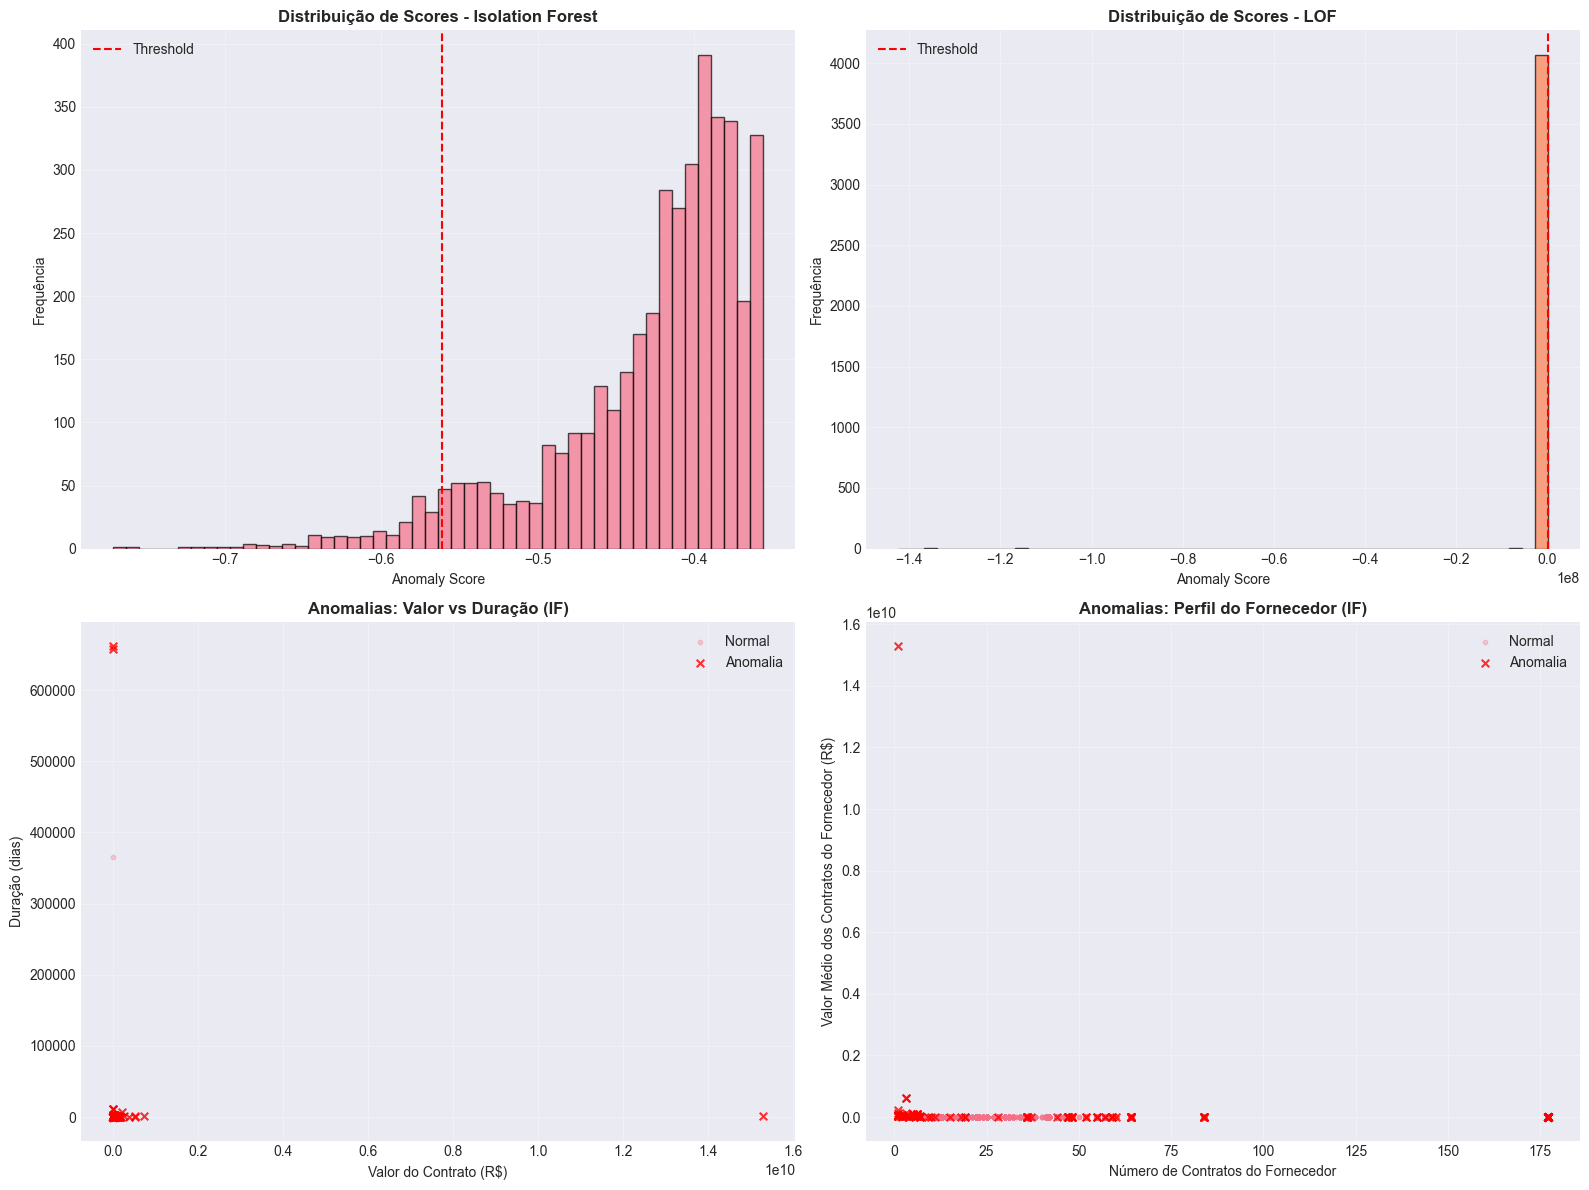

In [23]:
# Visualização de anomalias
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribuição de scores - Isolation Forest
axes[0, 0].hist(df_anomaly['anomaly_score_if'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df_anomaly[df_anomaly['anomaly_if'] == 1]['anomaly_score_if'].max(),
                   color='r', linestyle='--', label='Threshold')
axes[0, 0].set_xlabel('Anomaly Score')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição de Scores - Isolation Forest', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Distribuição de scores - LOF
axes[0, 1].hist(df_anomaly['anomaly_score_lof'], bins=50, alpha=0.7, 
                edgecolor='black', color='coral')
axes[0, 1].axvline(df_anomaly[df_anomaly['anomaly_lof'] == 1]['anomaly_score_lof'].max(),
                   color='r', linestyle='--', label='Threshold')
axes[0, 1].set_xlabel('Anomaly Score')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição de Scores - LOF', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Scatter: Valor vs Duração (com anomalias destacadas)
normal_if = df_anomaly[df_anomaly['anomaly_if'] == 0]
anomaly_if = df_anomaly[df_anomaly['anomaly_if'] == 1]

axes[1, 0].scatter(normal_if['valorcontrato1'], normal_if['duracao_dias'], 
                   alpha=0.3, s=10, label='Normal')
axes[1, 0].scatter(anomaly_if['valorcontrato1'], anomaly_if['duracao_dias'],
                   alpha=0.8, s=30, color='red', label='Anomalia', marker='x')
axes[1, 0].set_xlabel('Valor do Contrato (R$)')
axes[1, 0].set_ylabel('Duração (dias)')
axes[1, 0].set_title('Anomalias: Valor vs Duração (IF)', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Scatter: Fornecedor - Número de Contratos vs Valor Médio
axes[1, 1].scatter(normal_if['fornecedor_num_contratos'], normal_if['fornecedor_valor_medio'],
                   alpha=0.3, s=10, label='Normal')
axes[1, 1].scatter(anomaly_if['fornecedor_num_contratos'], anomaly_if['fornecedor_valor_medio'],
                   alpha=0.8, s=30, color='red', label='Anomalia', marker='x')
axes[1, 1].set_xlabel('Número de Contratos do Fornecedor')
axes[1, 1].set_ylabel('Valor Médio dos Contratos do Fornecedor (R$)')
axes[1, 1].set_title('Anomalias: Perfil do Fornecedor (IF)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.4 Análise Detalhada de Anomalias

In [24]:
# Anomalias detectadas por ambos os métodos
df_both_anomalies = df_anomaly[(df_anomaly['anomaly_if'] == 1) & 
                                (df_anomaly['anomaly_lof'] == 1)].copy()

print("ANÁLISE DETALHADA DE ANOMALIAS")
print("=" * 80)
print(f"\nAnomalias confirmadas por ambos os métodos: {len(df_both_anomalies):,}")

if len(df_both_anomalies) > 0:
    print("\nEstatísticas das anomalias confirmadas:")
    print("\nValor do Contrato:")
    print(f"  - Média: R$ {df_both_anomalies['valorcontrato1'].mean():,.2f}")
    print(f"  - Mediana: R$ {df_both_anomalies['valorcontrato1'].median():,.2f}")
    print(f"  - Mínimo: R$ {df_both_anomalies['valorcontrato1'].min():,.2f}")
    print(f"  - Máximo: R$ {df_both_anomalies['valorcontrato1'].max():,.2f}")
    
    print("\nDuração:")
    print(f"  - Média: {df_both_anomalies['duracao_dias'].mean():.0f} dias")
    print(f"  - Mediana: {df_both_anomalies['duracao_dias'].median():.0f} dias")
    
    print("\nComparação com população normal:")
    normal_contracts = df_anomaly[df_anomaly['anomaly_if'] == 0]
    print(f"  - Valor médio (normal): R$ {normal_contracts['valorcontrato1'].mean():,.2f}")
    print(f"  - Valor médio (anomalias): R$ {df_both_anomalies['valorcontrato1'].mean():,.2f}")
    print(f"  - Diferença: {(df_both_anomalies['valorcontrato1'].mean() / normal_contracts['valorcontrato1'].mean() - 1) * 100:.1f}%")

# Principais razões para anomalias
print("\n\nPRINCIPAIS CARACTERÍSTICAS DAS ANOMALIAS:")
print("=" * 80)

# Valores extremos
high_value_anomalies = df_both_anomalies[df_both_anomalies['valorcontrato1'] > 
                                          df_anomaly['valorcontrato1'].quantile(0.95)]
print(f"\n1. Contratos de valor muito alto: {len(high_value_anomalies):,}")

# Duração incomum
unusual_duration = df_both_anomalies[
    (df_both_anomalies['duracao_dias'] < df_anomaly['duracao_dias'].quantile(0.05)) |
    (df_both_anomalies['duracao_dias'] > df_anomaly['duracao_dias'].quantile(0.95))
]
print(f"2. Contratos com duração incomum: {len(unusual_duration):,}")

# Fornecedores com perfil incomum
unusual_supplier = df_both_anomalies[
    (df_both_anomalies['fornecedor_num_contratos'] > df_anomaly['fornecedor_num_contratos'].quantile(0.95)) |
    (df_both_anomalies['fornecedor_valor_medio'] > df_anomaly['fornecedor_valor_medio'].quantile(0.95))
]
print(f"3. Fornecedores com perfil incomum: {len(unusual_supplier):,}")

ANÁLISE DETALHADA DE ANOMALIAS

Anomalias confirmadas por ambos os métodos: 14

Estatísticas das anomalias confirmadas:

Valor do Contrato:
  - Média: R$ 1,290,656,485.05
  - Mediana: R$ 141,959,494.42
  - Mínimo: R$ 0.00
  - Máximo: R$ 15,295,275,720.00

Duração:
  - Média: 95506 dias
  - Mediana: 1094 dias

Comparação com população normal:
  - Valor médio (normal): R$ 1,054,225.74
  - Valor médio (anomalias): R$ 1,290,656,485.05
  - Diferença: 122327.0%


PRINCIPAIS CARACTERÍSTICAS DAS ANOMALIAS:

1. Contratos de valor muito alto: 11
2. Contratos com duração incomum: 6
3. Fornecedores com perfil incomum: 11


---

## 9. Insights e Conclusões Finais

In [25]:
print("PRINCIPAIS INSIGHTS - ANÁLISE PREDITIVA")
print("=" * 80)

print("\n1. PREDIÇÃO DE VALORES:")
best_reg_model = max(results_regression.items(), key=lambda x: x[1]['test_r2'])
print(f"   - Melhor modelo: {best_reg_model[0]}")
print(f"   - R² Score: {best_reg_model[1]['test_r2']:.4f}")
print(f"   - MAE: {best_reg_model[1]['test_mae']:.4f}")
print(f"   - Interpretação: O modelo explica {best_reg_model[1]['test_r2']*100:.1f}% da variância")

print("\n2. CLASSIFICAÇÃO DE CONTRATOS:")
best_clf_model = max(results_classification.items(), key=lambda x: x[1]['test_accuracy'])
print(f"   - Melhor modelo: {best_clf_model[0]}")
print(f"   - Acurácia: {best_clf_model[1]['test_accuracy']:.4f}")
print(f"   - Categorias classificadas: {len(main_categories)}")
print(f"   - Interpretação: {best_clf_model[1]['test_accuracy']*100:.1f}% de precisão na categorização")

print("\n3. DETECÇÃO DE ANOMALIAS:")
print(f"   - Anomalias (Isolation Forest): {(df_anomaly['anomaly_if'] == 1).sum():,} ({(df_anomaly['anomaly_if'] == 1).sum() / len(df_anomaly) * 100:.2f}%)")
print(f"   - Anomalias (LOF): {(df_anomaly['anomaly_lof'] == 1).sum():,} ({(df_anomaly['anomaly_lof'] == 1).sum() / len(df_anomaly) * 100:.2f}%)")
print(f"   - Anomalias confirmadas: {both_anomalies:,}")
print(f"   - Interpretação: Identificados contratos com padrões atípicos que merecem investigação")

print("\n4. FEATURES MAIS IMPORTANTES:")
print("   Para predição de valor:")
top_5_features = [(feature_names[i], importances[i]) for i in indices[:5]]
for feat, imp in top_5_features:
    print(f"     - {feat}: {imp:.4f}")

print("\n5. APLICAÇÕES PRÁTICAS:")
print("   - Estimativa de valores: Prever custos de novos contratos")
print("   - Categorização automática: Classificar contratos automaticamente")
print("   - Auditoria: Identificar contratos anômalos para investigação")
print("   - Planejamento: Otimizar processos de contratação")

print("\n6. RECOMENDAÇÕES:")
print("   - Investigar anomalias confirmadas por múltiplos métodos")
print("   - Usar predições para validar orçamentos propostos")
print("   - Implementar sistema de alertas automáticos")
print("   - Retreinar modelos periodicamente com novos dados")
print("   - Considerar features adicionais (sazonalidade, contexto econômico)")

PRINCIPAIS INSIGHTS - ANÁLISE PREDITIVA

1. PREDIÇÃO DE VALORES:
   - Melhor modelo: Random Forest
   - R² Score: 0.7302
   - MAE: 0.7244
   - Interpretação: O modelo explica 73.0% da variância

2. CLASSIFICAÇÃO DE CONTRATOS:
   - Melhor modelo: Gradient Boosting
   - Acurácia: 0.5937
   - Categorias classificadas: 8
   - Interpretação: 59.4% de precisão na categorização

3. DETECÇÃO DE ANOMALIAS:
   - Anomalias (Isolation Forest): 204 (5.00%)
   - Anomalias (LOF): 203 (4.98%)
   - Anomalias confirmadas: 14
   - Interpretação: Identificados contratos com padrões atípicos que merecem investigação

4. FEATURES MAIS IMPORTANTES:
   Para predição de valor:
     - fornecedor_valor_mediano: 0.5897
     - fornecedor_valor_medio: 0.1824
     - duracao_dias: 0.0425
     - orgao_valor_mediano: 0.0316
     - orgao_num_fornecedores: 0.0250

5. APLICAÇÕES PRÁTICAS:
   - Estimativa de valores: Prever custos de novos contratos
   - Categorização automática: Classificar contratos automaticamente
   - 

## 10. Exportação de Resultados

In [28]:
# Salvar modelos treinados (exemplo com pickle)
import pickle

# Salvar melhor modelo de regressão
with open('../../../data/pe/recife/modelo_regressao.pkl', 'wb') as f:
    if best_reg_model[0] == 'Random Forest':
        pickle.dump(rf_pipeline, f)
    elif best_reg_model[0] == 'Gradient Boosting':
        pickle.dump(gb_pipeline, f)
    else:
        pickle.dump(lr_pipeline, f)
print(f"Modelo de regressão ({best_reg_model[0]}) salvo!")

# Salvar melhor modelo de classificação
with open('../../../data/pe/recife/modelo_classificacao.pkl', 'wb') as f:
    if best_clf_model[0] == 'Random Forest':
        pickle.dump(rf_clf_pipeline, f)
    else:
        pickle.dump(gb_clf_pipeline, f)
print(f"Modelo de classificação ({best_clf_model[0]}) salvo!")

# Salvar anomalias detectadas
df_anomalies_export = df_anomaly[df_anomaly['anomaly_if'] == 1].copy()
df_anomalies_export.to_csv('../../../data/pe/recife/anomalias_detectadas.csv',
                            index=False, encoding='utf-8', sep=';')
print(f"Anomalias salvas: {len(df_anomalies_export):,} contratos")

# Salvar métricas dos modelos
results_df_reg = pd.DataFrame(results_regression).T
results_df_reg.to_csv('../../../data/pe/recife/metricas_regressao.csv',
                      encoding='utf-8', sep=';')
print("Métricas de regressão salvas!")

results_df_clf = pd.DataFrame(results_classification).T
results_df_clf.to_csv('../../../data/pe/recife/metricas_classificacao.csv',
                      encoding='utf-8', sep=';')
print("Métricas de classificação salvas!")

print("\nTodos os resultados foram exportados com sucesso!")

Modelo de regressão (Random Forest) salvo!
Modelo de classificação (Gradient Boosting) salvo!
Anomalias salvas: 204 contratos
Métricas de regressão salvas!
Métricas de classificação salvas!

Todos os resultados foram exportados com sucesso!


---

## Conclusão

Esta análise preditiva implementou três abordagens complementares de Machine Learning:

### 1. Predição de Valores
- Modelos testados: Regressão Linear, Random Forest, Gradient Boosting
- Features: Características do contrato, histórico do fornecedor e órgão
- Objetivo: Estimar valores de novos contratos com base em características conhecidas

### 2. Classificação de Contratos
- Categorização automática em 10+ categorias temáticas
- Modelos: Random Forest e Gradient Boosting Classifiers
- Aplicação: Organização e análise automatizada de grandes volumes de contratos

### 3. Detecção de Anomalias
- Algoritmos: Isolation Forest e Local Outlier Factor
- Identificação de contratos com padrões atípicos
- Útil para auditoria e identificação de casos que requerem investigação

### Valor Prático

Os modelos desenvolvidos podem ser aplicados para:
- **Planejamento Orçamentário**: Estimar custos de futuros contratos
- **Controle de Qualidade**: Identificar valores inconsistentes
- **Auditoria Inteligente**: Priorizar contratos para revisão detalhada
- **Automação**: Categorizar e processar contratos automaticamente
- **Transparência**: Fornecer baseline para avaliação de propostas

### Próximos Passos

- Incorporar features temporais (sazonalidade, tendências)
- Testar modelos mais sofisticados (XGBoost, LightGBM, Neural Networks)
- Implementar sistema de monitoramento contínuo
- Desenvolver API para predições em tempo real
- Criar dashboards interativos com as predições